In [1]:
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, rdMolDescriptors

In [39]:
smiles_dict = {
    'IBP': {
        'full_name': 'Ibuprofen',
        'smiles': 'O=C(O)C(C1=CC=C(C=C1)CC(C)C)C'
    },

    'DCF': {
        'full_name': 'Diclofenac',
        'smiles': 'O=C(O)CC=1C=CC=CC1NC=2C(Cl)=CC=CC2Cl'

    },

    'LOV': {
        'full_name': 'Lovastatin',
        'smiles': 'O=C1OC(CCC2C(C=CC3=CC(C)CC(OC(=O)C(C)CC)C32)C)CC(O)C1'
    },


    'ITZ': {
        'full_name': 'Itraconazole',
        'smiles': 'O=C1N(N=CN1C2=CC=C(C=C2)N3CCN(C4=CC=C(OCC5OC(OC5)(C6=CC=C(Cl)C=C6Cl)CN7N=CN=C7)C=C4)CC3)C(C)CC'
    },

    'RPD': {
        'full_name': 'Risperidone',
        'smiles': 'O=C1C(=C(N=C2N1CCCC2)C)CCN3CCC(C4=NOC=5C=C(F)C=CC54)CC3'
    }

}


In [40]:

def print_drug_properties(drug_name):

    if drug_name not in smiles_dict:
        print(f"Drug '{drug_name}' not found in dictionary.")
        return

    smiles = smiles_dict[drug_name]['smiles']
    mol = Chem.MolFromSmiles(smiles)
    
    if mol is None:
        print(f"Invalid SMILES for drug '{drug_name}': {smiles}")
        return

    mol_weight = Descriptors.MolWt(mol)
    logp = Crippen.MolLogP(mol)
    tpsa = rdMolDescriptors.CalcTPSA(mol)

    # Normalized properties
    norm_weight = mol_weight / 1000
    norm_logp = logp / 10
    norm_tpsa = tpsa / 1000

    print(f"Drug: {smiles_dict[drug_name]['full_name']} ({drug_name})")
    print()
    print(f"Molecular Weight           : {mol_weight:.2f}")
    print(f"LogP                       : {logp:.2f}")
    print(f"TPSA                       : {tpsa:.2f}")
    print()
    print(f"Normalized Molecular Weight: {norm_weight:.3f}")
    print(f"Normalized LogP            : {norm_logp:.3f}")
    print(f"Normalized TPSA            : {norm_tpsa:.3f}")

    return {

        "name": drug_name,
        "full_name": smiles_dict[drug_name]['full_name'],
        "abbr": drug_name,
        "molecular_weight": mol_weight,
        "logp": logp,
        "tpsa": tpsa,
    }




In [41]:
ibp_property = print_drug_properties('IBP')

Drug: Ibuprofen (IBP)

Molecular Weight           : 206.28
LogP                       : 3.07
TPSA                       : 37.30

Normalized Molecular Weight: 0.206
Normalized LogP            : 0.307
Normalized TPSA            : 0.037


In [42]:
dcf_property = print_drug_properties('DCF')

Drug: Diclofenac (DCF)

Molecular Weight           : 296.15
LogP                       : 4.36
TPSA                       : 49.33

Normalized Molecular Weight: 0.296
Normalized LogP            : 0.436
Normalized TPSA            : 0.049


In [43]:
lov_property = print_drug_properties('LOV')

Drug: Lovastatin (LOV)

Molecular Weight           : 404.55
LogP                       : 4.20
TPSA                       : 72.83

Normalized Molecular Weight: 0.405
Normalized LogP            : 0.420
Normalized TPSA            : 0.073


In [44]:
itz_property = print_drug_properties('ITZ')

Drug: Itraconazole (ITZ)

Molecular Weight           : 705.65
LogP                       : 5.58
TPSA                       : 104.70

Normalized Molecular Weight: 0.706
Normalized LogP            : 0.558
Normalized TPSA            : 0.105


In [45]:
rpd_property = print_drug_properties('RPD')

Drug: Risperidone (RPD)

Molecular Weight           : 410.49
LogP                       : 3.59
TPSA                       : 64.16

Normalized Molecular Weight: 0.410
Normalized LogP            : 0.359
Normalized TPSA            : 0.064


In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_drug_properties_boxplots(base_drug_properties, target_drug_properties):
    property_names = ['molecular_weight', 'logp', 'tpsa']
    base_df = pd.DataFrame(base_drug_properties)
    target_df = pd.DataFrame(target_drug_properties)

    # Create a single figure with 3 subplots
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

    for i, prop in enumerate(property_names):
        ax = axes[i]

        # Boxplot of base drugs
        sns.boxplot(y=base_df[prop], ax=ax, color='lightblue', width=0.3)

        # Scatter plot of target drugs
        for j, row in target_df.iterrows():
            ax.scatter(0, row[prop], color='red', zorder=5, label=row['name'] if j == 0 else "")

        # Aesthetics
        ax.set_title(f'{prop.replace("_", " ").title()}')
        ax.set_ylabel('')
        ax.set_xlabel('')
        ax.set_xticks([])

        # Add legend only to first subplot if multiple target drugs
        if i == 0 and len(target_df) > 0:
            ax.legend()

    fig.suptitle('Base Drug Properties with Target Drug Overlay', fontsize=16)
    plt.show()


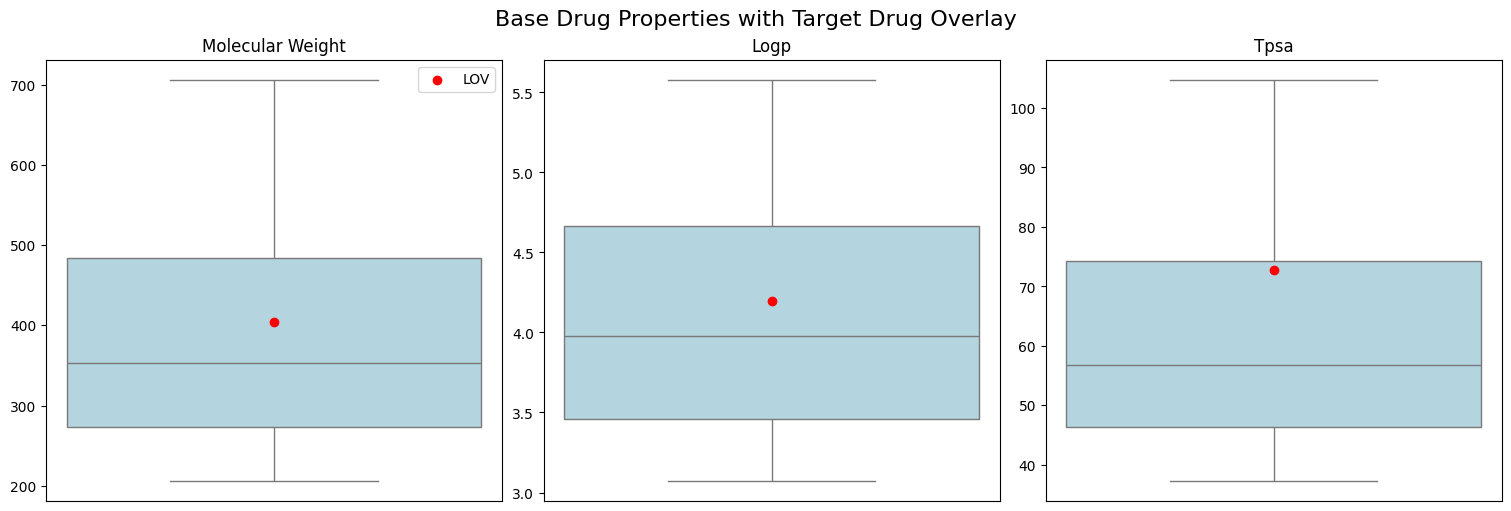

In [ ]:
base_drug_properties = [ibp_property, dcf_property , itz_property, rpd_property]
target_drug_properties = [lov_property]

plot_drug_properties_boxplots(base_drug_properties, target_drug_properties)
